In [15]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from qiskit_signals.quantum_axis import (
    AngularWavenumberAxis,
    EncodingType,
    PositionAxis,
)
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.visualization import plot_wavefunction

### Initial parameters


In [16]:
# beam parameters
# vacuum_wavelength = 1e-6
vacuum_wavelength = 1e-6 * 1e1
# beam_FWHM = 5e-3 * 1e-2
beam_FWHM = 20e-3 * 1e-2

# lens parameters
focal_length = 200e-3 * 1e-2
# lens_diameter = 25e-3
# refractive_index = 1.5
refractive_index = 1.25

# free space propagation parameters
propagation_after_lens = 1.5 * focal_length

# simulation parameters
transverse_length = 100e-3 * 1e-2  # transverse simulation window
num_of_steps_after_lens = 10
lens_slices = 1000
# num_qubits = 10
num_qubits = 8
max_delta = 0.0001

# lens_diameter = 50e-3 * 1e-2
lens_diameter = transverse_length

### Constants


In [17]:
c = constants.c
# hbar = constants.hbar

### Derived parameters


In [18]:
# geometry
radius_of_curvature = focal_length * (refractive_index - 1)
lens_radius = lens_diameter / 2
lens_thickness = radius_of_curvature - np.sqrt(radius_of_curvature**2 - lens_radius**2)


k_0 = 2 * constants.pi / vacuum_wavelength
reduced_wavelength = vacuum_wavelength / refractive_index

dimension = 2**num_qubits
delta_x = transverse_length / dimension

gaussian_mean = transverse_length / 2
gaussian_beam_waist = beam_FWHM / np.sqrt(2 * np.log(2))
# gaussian_sigma = gaussian_beam_waist / np.sqrt(2)

# vacuum_rayleigh_length = (np.pi * gaussian_beam_waist**2) / vacuum_wavelength

lens_slice_thickness = lens_thickness / lens_slices
# step_size_after_lens = propagation_after_lens / num_of_steps_after_lens

In [19]:
print(delta_x, vacuum_wavelength)

3.90625e-06 9.999999999999999e-06


In [20]:
x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)
twos_complement_x_axis = PositionAxis(
    num_qubits=num_qubits,
    delta_x=delta_x,
    encoding=EncodingType.TWOS_COMPLEMENT_MIRRORED,
)
k_axis = AngularWavenumberAxis.from_position_axis(x_axis)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

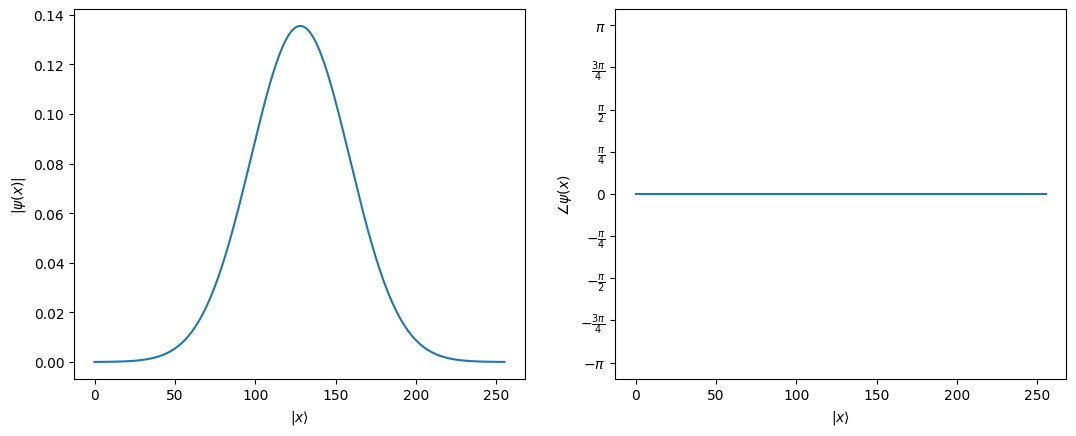

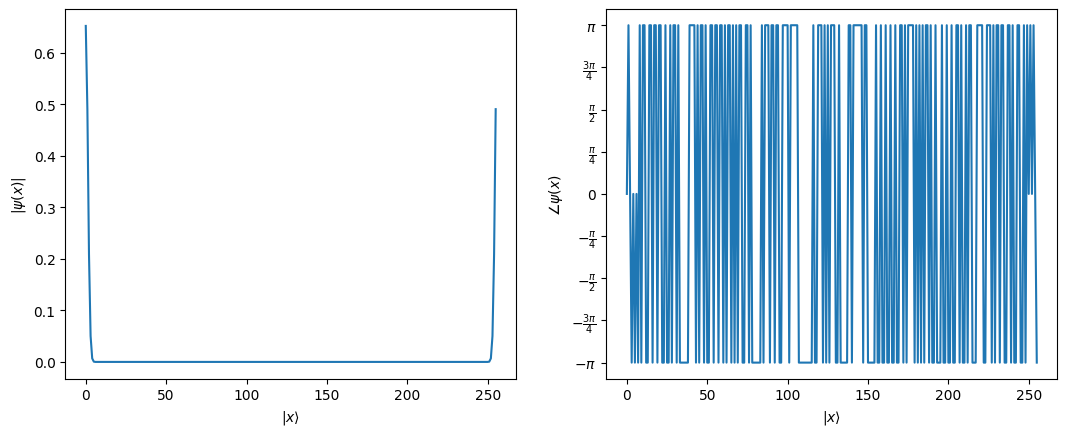

In [21]:
initial_wavefunction = gaussian_signal(
    x_axis,
    gaussian_beam_waist,
    gaussian_mean,
)
plot_wavefunction(initial_wavefunction.data)
plot_wavefunction(np.fft.fft(initial_wavefunction.data, norm="ortho"))

A lens applies a phase as

$$
e^{-ik_0\frac{x^2}{2f}}
$$


-16384.0


(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

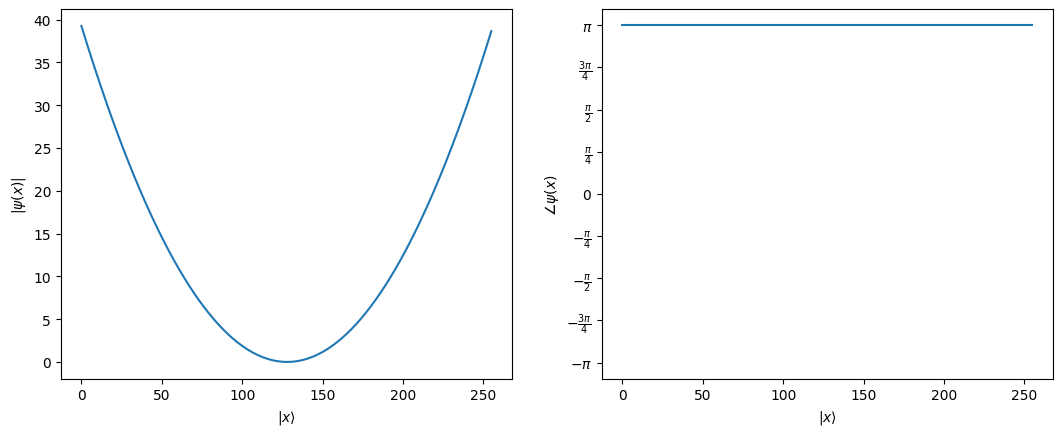

In [22]:
from qiskit_signals.quantum_signal import PolynomialQuantumSignal

lens_signal = PolynomialQuantumSignal(
    axis=twos_complement_x_axis, alpha=-k_0 / 2 / focal_length, power=2
)

print((lens_signal.data / k_0 * 2 * focal_length / delta_x**2).min())
plot_wavefunction(lens_signal.data, normalize=False)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

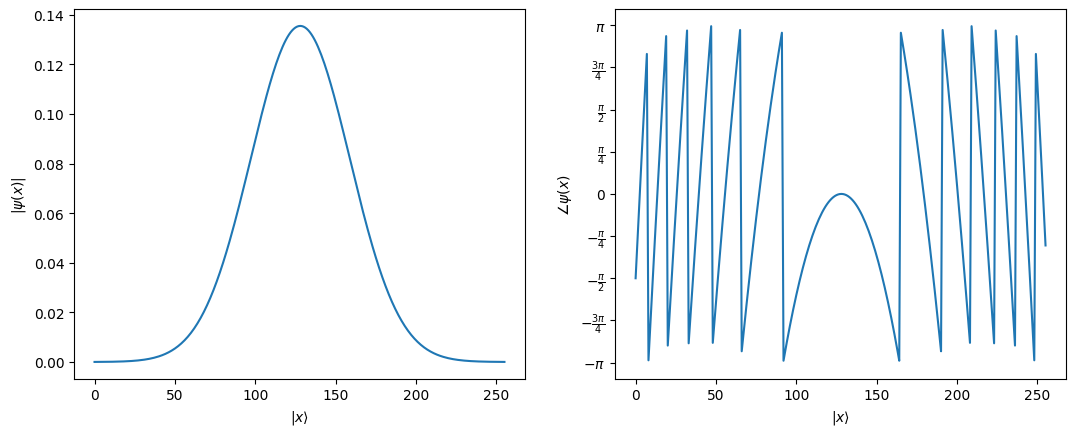

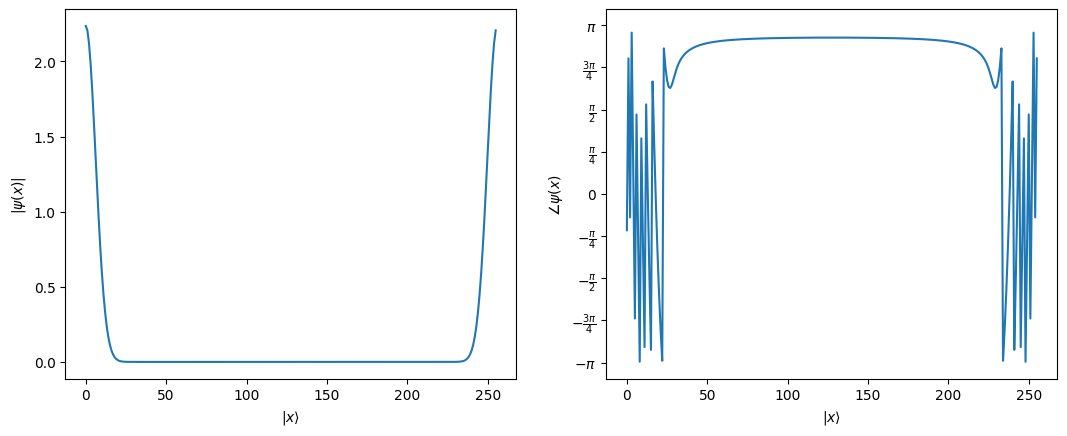

In [23]:
wavefront_after_lens = initial_wavefunction.data * np.exp(1j * lens_signal.data)
plot_wavefunction(wavefront_after_lens)
plot_wavefunction(np.fft.fft(wavefront_after_lens, norm="ortho"), normalize=False)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

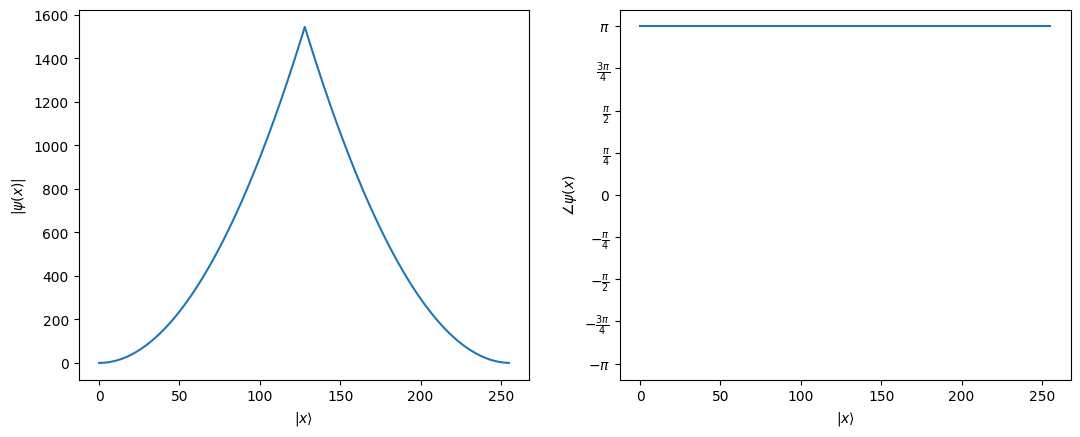

In [24]:
from wave_optics_propagation.elements import free_space_signal_generator

free_space_signal = free_space_signal_generator(
    k_axis,
    delta_t=propagation_after_lens / constants.c,
    wavelength=vacuum_wavelength,
    c=constants.c,
)

plot_wavefunction(free_space_signal.data, normalize=False)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

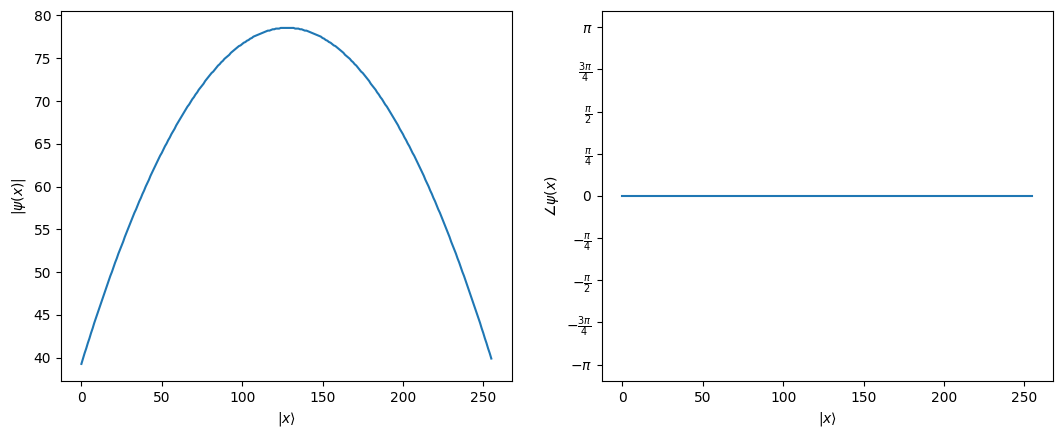

In [25]:
from wave_optics_propagation.elements import (
    radius_of_convex_planar_lens_as_a_func_of_z,
    thin_transparent_plate_signal_generator,
)

lens_slice_positions = (
    np.linspace(0, lens_thickness, lens_slices, endpoint=False)
    + lens_slice_thickness / 2
)  # choosing the midpoint in each transverse slice

lens_transverse_radii = [
    radius_of_convex_planar_lens_as_a_func_of_z(
        radius_of_curvature, z, lens_thickness, fresnel_approximation=True
    )
    for z in lens_slice_positions
]


lens_signals = [
    thin_transparent_plate_signal_generator(
        x_axis=x_axis,
        refractive_index=refractive_index,
        thickness=lens_slice_thickness,
        radius=lens_radius,
        wavelength=vacuum_wavelength,
        scale_down=True,
        # scale_down=False,
    )
    for lens_radius in lens_transverse_radii
]

sum_signal = np.zeros_like(lens_signals[0].data)
for signal in lens_signals:
    sum_signal += signal.data

plot_wavefunction(sum_signal, normalize=False)

[78.53981634 78.5569394  78.57885615 78.52702677 78.55853091 78.51628891
 78.55738042 78.5247258  78.57540469 78.55233746 78.53406391 78.52058406
 78.51189789 78.50800541 78.50890663 78.51460153 78.52509012 78.54037241
 78.56044838 78.50677823 78.53644158 78.57089863 78.53160954 78.57565397
 78.54595226 78.52104425 78.50092993 78.56414911 78.55362217 78.54788891
 78.54694935 78.55080348 78.55945129 78.5728928  78.51258818 78.53561707
 78.56343964 78.51751609 78.55492605 78.51858988 78.56558722 78.53883843
 78.51688333 78.57826173 78.56589401 78.55831998 78.55553964 78.55755299
 78.56436003 78.57596076 78.51381537 78.53500348 78.56098527 78.51322095
 78.54879013 78.51061318 78.55576974 78.52718017 78.5033843  78.56292193
 78.54871343 78.53929862 78.5346775  78.53485008 78.53981634 78.54957629
 78.56412994 78.50493745 78.52907847 78.55801319 78.51320177 78.55172387
 78.51649983 78.5646093  78.53897265 78.51812969 78.50208041 78.56936464
 78.56290275 78.56123455 78.56436003 78.57227921 78

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

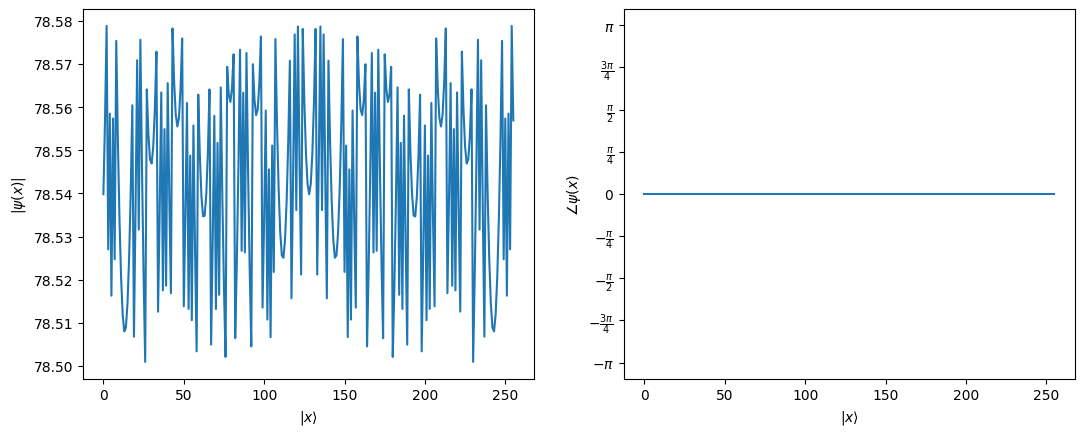

In [26]:
print(sum_signal - lens_signal.data)
print(sum_signal[0], lens_signal.data[0])
print(sum_signal[len(sum_signal) // 2], lens_signal.data[len(lens_signal.data) // 2])
print(
    refractive_index * k_0 * lens_thickness / 3, refractive_index * k_0 * lens_thickness
)
# assert np.allclose(sum_signal, lens_signal.data)
plot_wavefunction(sum_signal - lens_signal.data, normalize=False)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

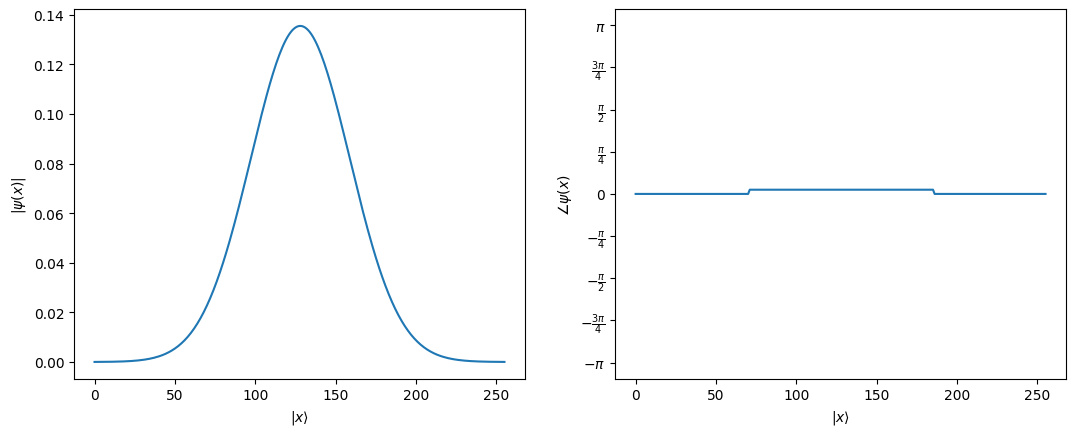

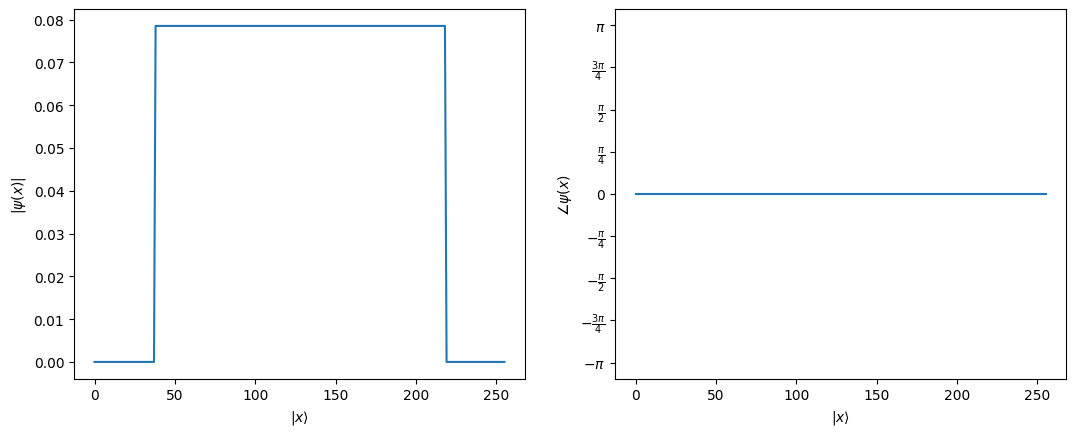

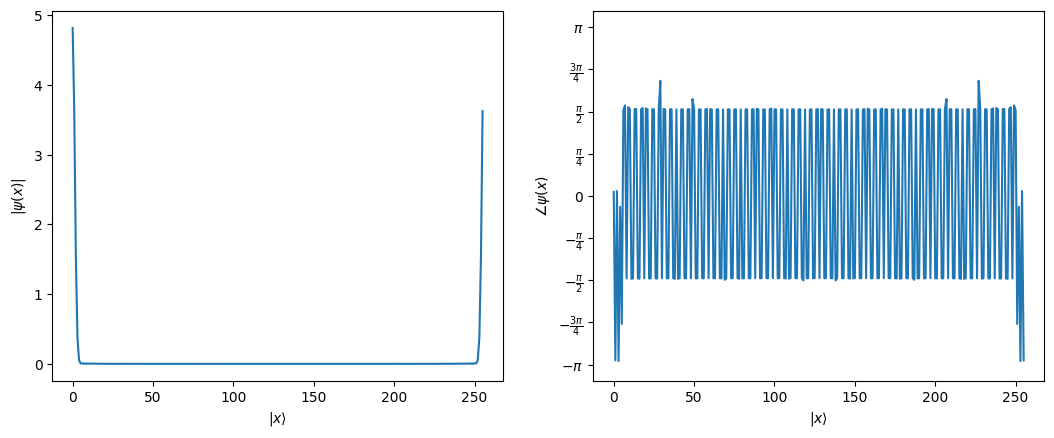

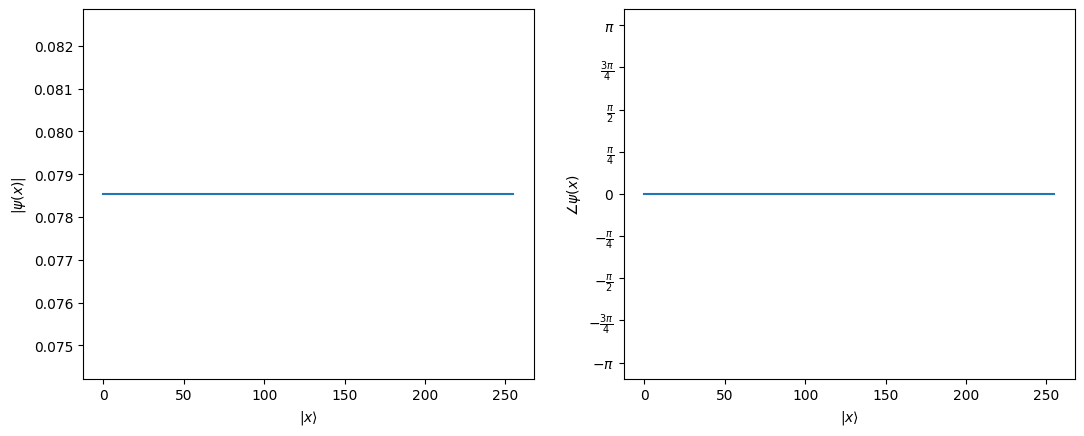

In [27]:
signal_data = initial_wavefunction.data.copy()
signal_data = signal_data * np.exp(1j * lens_signals[lens_slices // 10].data)
plot_wavefunction(signal_data)
plot_wavefunction(lens_signals[lens_slices // 4].data, normalize=False)
plot_wavefunction(np.fft.fft(signal_data, norm="ortho"), normalize=False)
plot_wavefunction(lens_signals[-lens_slices // 10].data, normalize=False)

Doing lens slice 1/1000
max value in signal: 0.07853981633974483
sum of amplitude square: 0.05551652475612764
Doing lens slice 2/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 3/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 4/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 5/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 6/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 7/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 8/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 9/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 10/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 11/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 12/1000
Skipped the lens slice because it is a flat phase.
Doing lens slice 13/1000
Skipped the lens slice because it is 

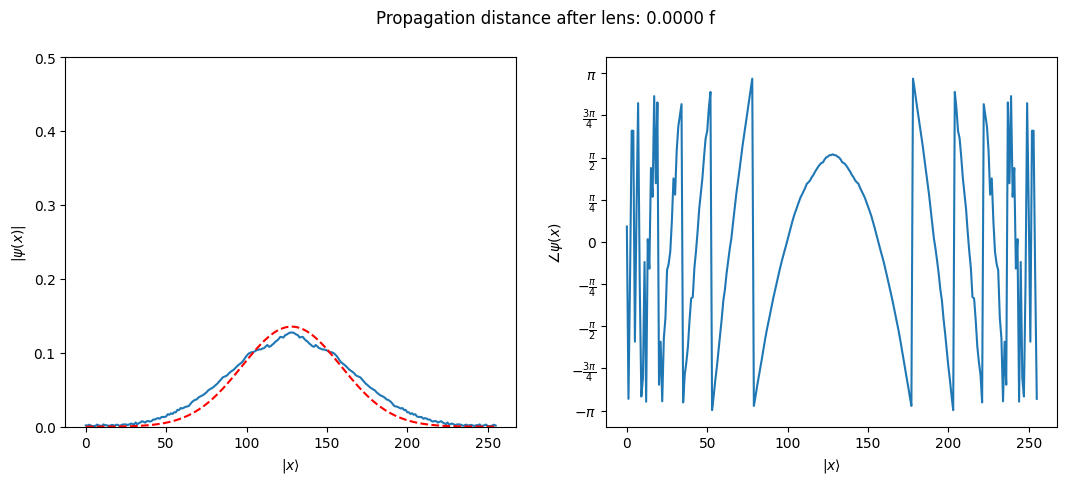

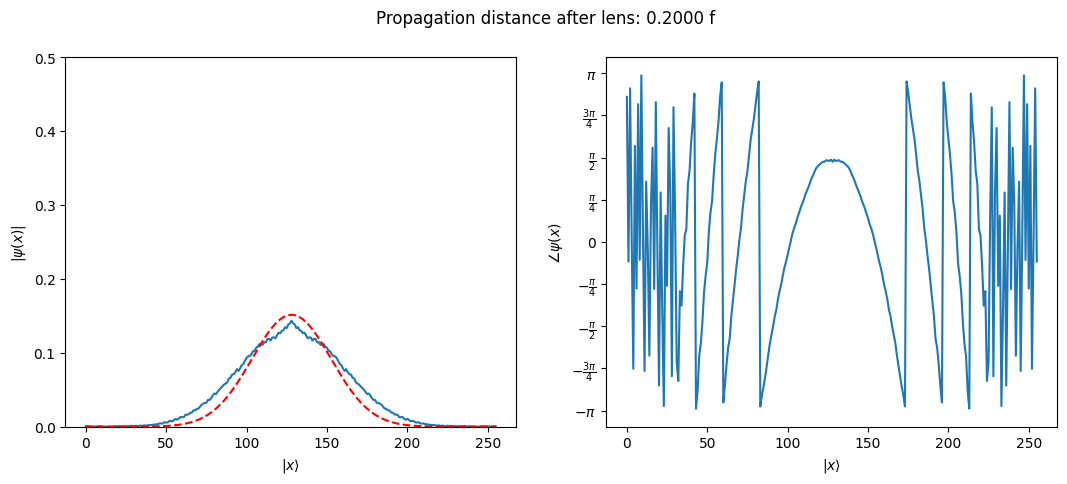

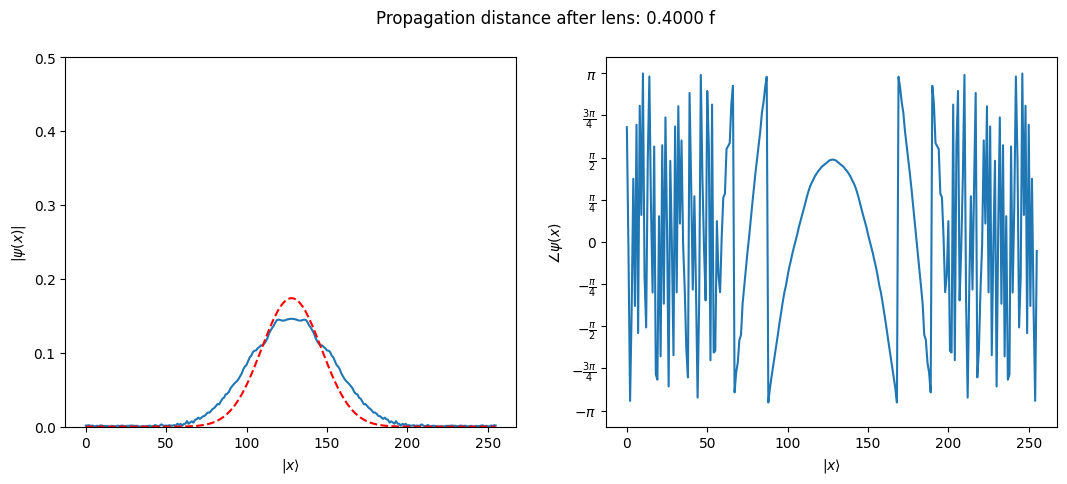

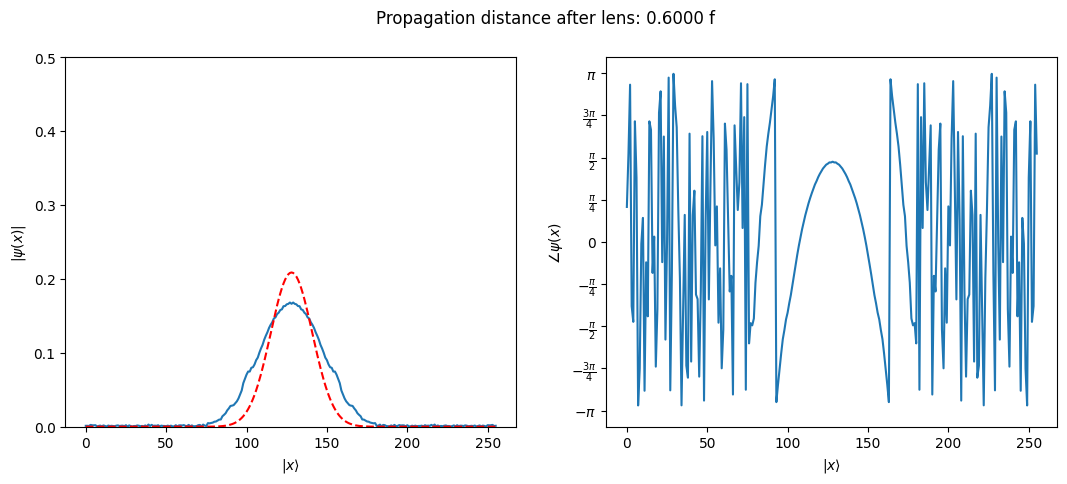

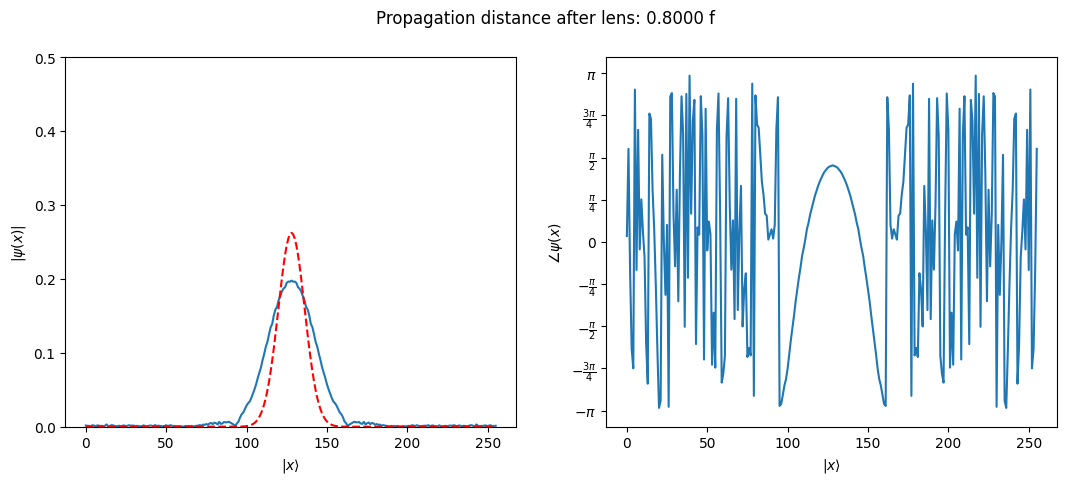

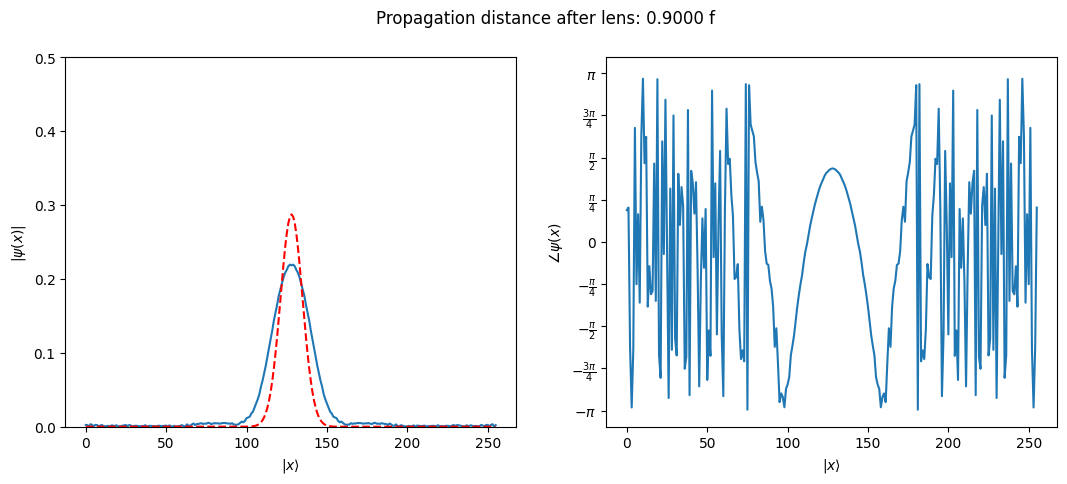

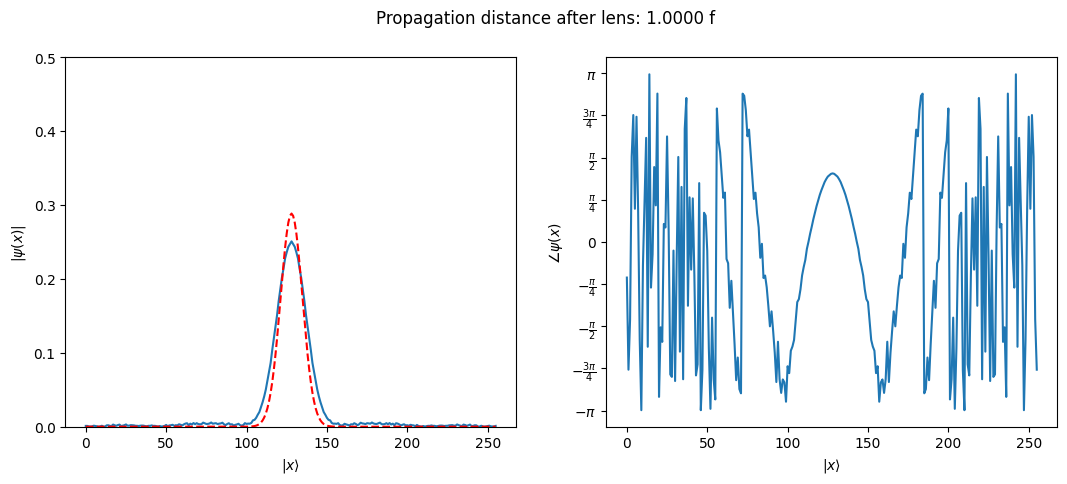

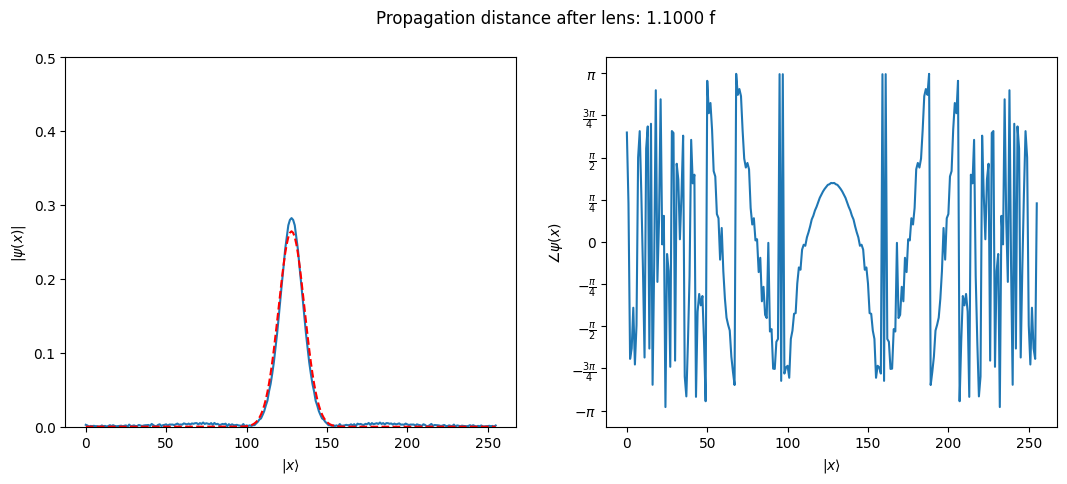

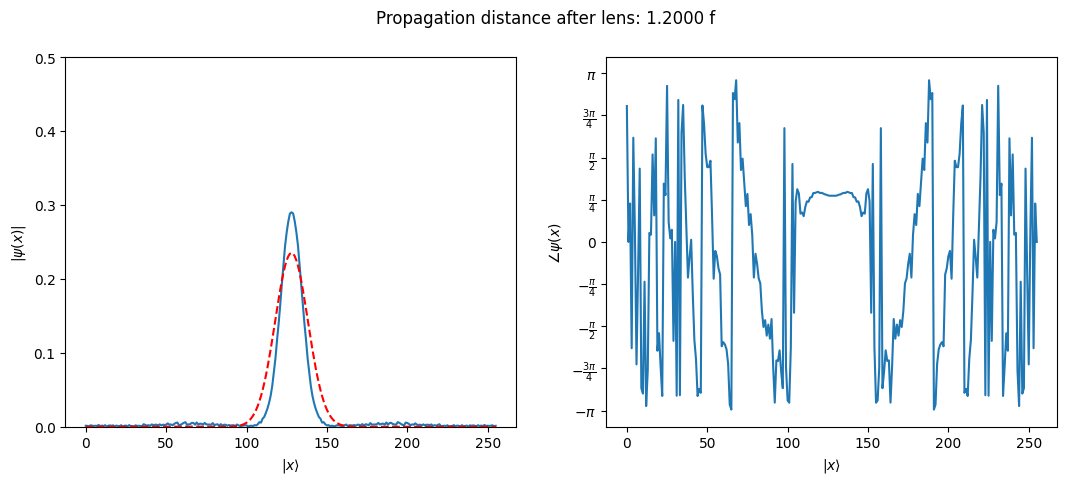

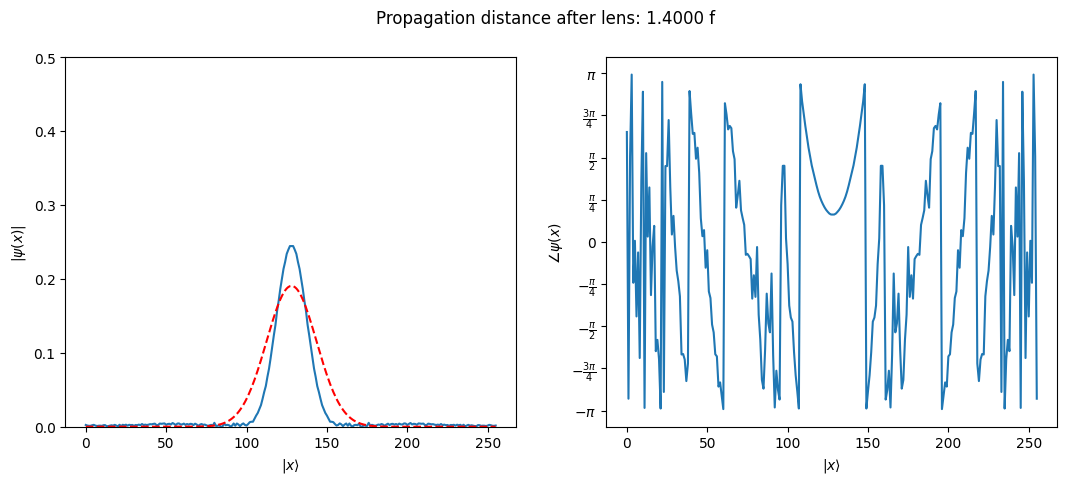

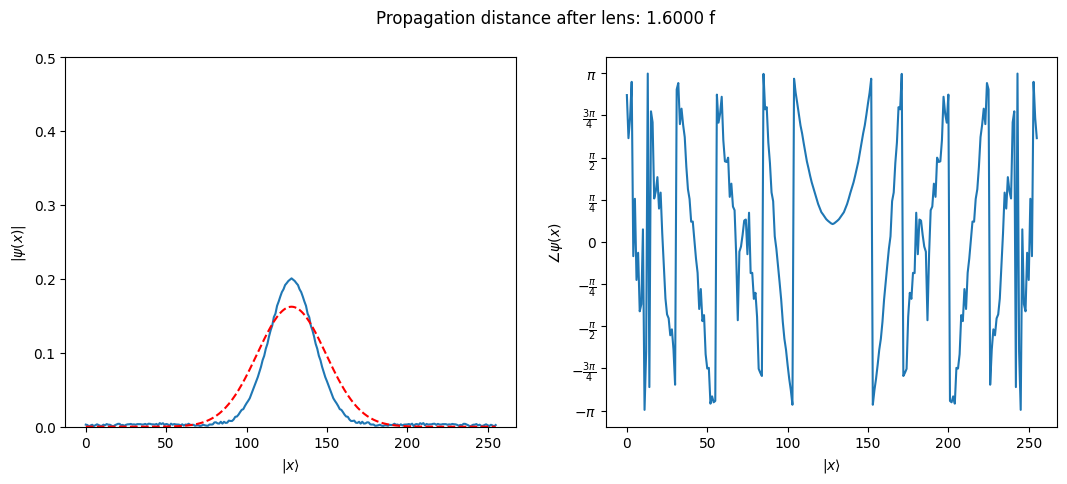

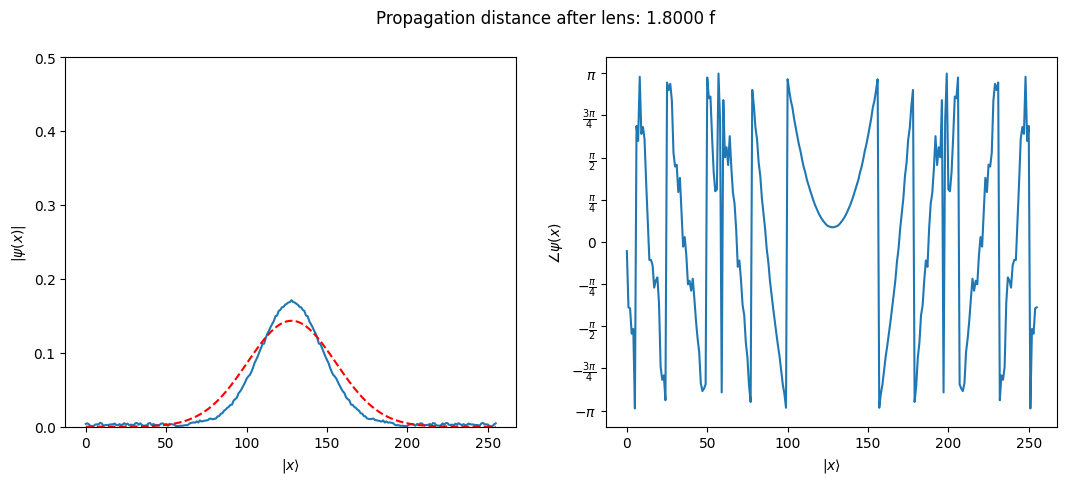

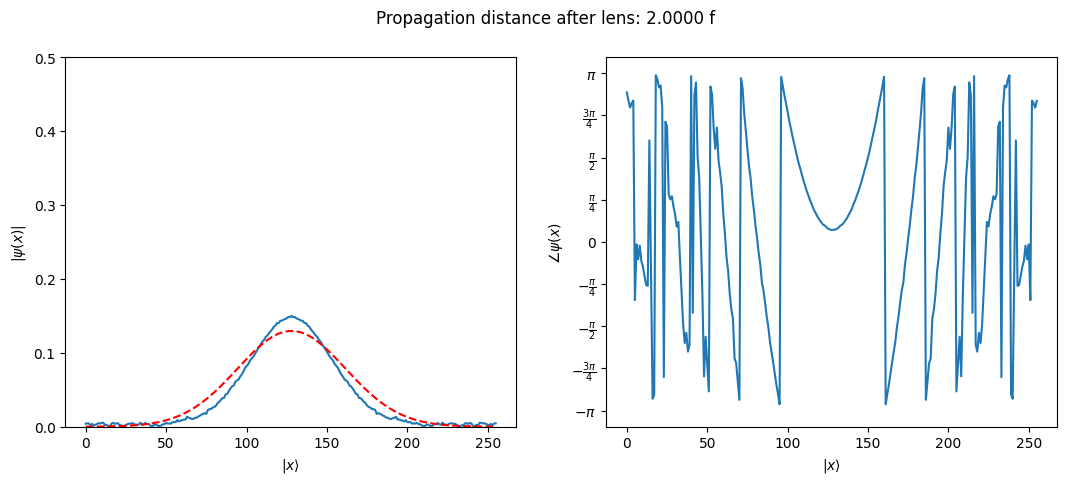

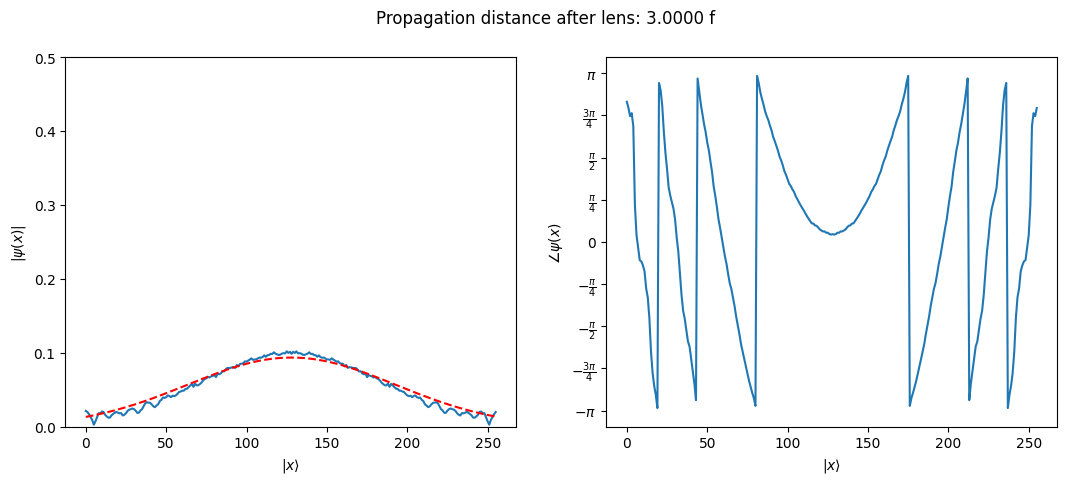

In [28]:
zs = (
    np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 3.0])
) * focal_length - lens_thickness

for z in zs:
    inside_lens_propagation_remained = lens_thickness
    total_lenses_simulated = 0
    signal_data = initial_wavefunction.data.copy()
    step_size_after_lens = z / num_of_steps_after_lens

    for i, lens_radius in enumerate(lens_transverse_radii):
        print(f"Doing lens slice {i + 1}/{lens_slices}")

        lens_signal_loop = lens_signals[-i]

        if not np.isclose(np.std(lens_signal_loop.data), 0):
            print(f"max value in signal: {np.max(np.abs(lens_signal_loop.data))}")
            print(
                f"sum of amplitude square: {np.sum(np.abs(lens_signal_loop.data) ** 2)}"
            )
            # continue
            signal_data = signal_data * np.exp(1j * lens_signal_loop.data)
            total_lenses_simulated += 1

        else:
            print("Skipped the lens slice because it is a flat phase.")

        propagator_signal = free_space_signal_generator(
            k_axis=k_axis,
            delta_t=lens_slice_thickness / c,
            wavelength=vacuum_wavelength,
            c=constants.c,
        )

        fourier_transformed = np.fft.fft(signal_data, norm="ortho")
        propagated = fourier_transformed * np.exp(1j * propagator_signal.data)
        signal_data = np.fft.ifft(propagated, norm="ortho")

        inside_lens_propagation_remained -= lens_slice_thickness

    # remaining propagation once the lens slice grows larger than the simulation window
    while inside_lens_propagation_remained > 0:
        propagator_signal = free_space_signal_generator(
            k_axis=k_axis,
            delta_t=inside_lens_propagation_remained / c,
            wavelength=reduced_wavelength,
            c=constants.c,
        )

        fourier_transformed = np.fft.fft(signal_data, norm="ortho")
        propagated = fourier_transformed * np.exp(1j * propagator_signal.data)
        signal_data = np.fft.ifft(propagated, norm="ortho")

        inside_lens_propagation_remained -= inside_lens_propagation_remained

    for i in range(num_of_steps_after_lens):
        print(f"Doing free space step {i + 1}/{num_of_steps_after_lens}")

        propagator_signal = free_space_signal_generator(
            k_axis=k_axis,
            delta_t=step_size_after_lens / c,
            wavelength=vacuum_wavelength,
            c=constants.c,
        )

        fourier_transformed = np.fft.fft(signal_data, norm="ortho")
        propagated = fourier_transformed * np.exp(1j * propagator_signal.data)
        signal_data = np.fft.ifft(propagated, norm="ortho")

    fig, (ax1, ax2) = plot_wavefunction(signal_data, fixed_ylim=0.5)

    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist,
        # z,
        z + lens_thickness,
        focal_length,
        vacuum_wavelength,
        1,
    )

    signal_with_lens = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(signal_with_lens.data / np.linalg.norm(signal_with_lens.data), "r--")

    fig.suptitle(
        f"Propagation distance after lens: {(z + lens_thickness) / focal_length:.4f} f"
    )
